# *Google Play Store dataset*

**lets gooooooooooooooooooooooo*

In [1]:
# import the libraries
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#fetch the dataset
# Fetch the dataset

df = pd.read_csv("googleplaystore.csv")

## Understand the basics related to dataset

In [3]:
# First 5 rows
print(df.head())

# Last 5 rows
print(df.tail())

# Shape of dataset
print("Shape:", df.shape)

# Column names
print("Columns:")
print(df.columns)

# Information about dataset
print("\nDataset Info:")
df.info()

# Data types
print("\nData Types:")
print(df.dtypes)

# Statistical summary
print("\nSummary:")
print(df.describe())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend 

### **What is the shape of the dataset?*

In [4]:
print(df.shape)

(10841, 13)


What are the data types of all columns? and Find out the name of all the columns

In [5]:
# Data types of all columns
print(df.dtypes)
# Name of all columns
print(df.columns)
# Print column names one by one
for i in df.columns:
    print(i)

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object
Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')
App
Category
Rating
Reviews
Size
Installs
Type
Price
Content Rating
Genres
Last Updated
Current Ver
Android Ver


Which columns contain missing values?

In [6]:
print(df.isnull().sum())
# Columns with missing values
missing = df.isnull().sum()
print(missing[missing > 0])

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64
Rating            1474
Type                 1
Content Rating       1
Current Ver          8
Android Ver          3
dtype: int64


What percentage of values are missing in each column?

In [7]:
missing_values=df.isnull().sum()
print("Missing Values:")
print(missing_values)

missing_percentage=(df.isnull().sum()/len(df))*100
print("\nMissing Percentage:")
print(missing_percentage)

Missing Values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Missing Percentage:
App                0.000000
Category           0.000000
Rating            13.596532
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009224
Price              0.000000
Content Rating     0.009224
Genres             0.000000
Last Updated       0.000000
Current Ver        0.073794
Android Ver        0.027673
dtype: float64


Find out the numerical  columns and categorical columns separately

In [8]:
num_col=df.select_dtypes(include=["int64","float64"]).columns
cat_col=df.select_dtypes(include=["object"]).columns
print("Numerical Columns:")
print(num_col)
print("\nCategorical Columns:")
print(cat_col)

Numerical Columns:
Index(['Rating'], dtype='object')

Categorical Columns:
Index(['App', 'Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


How many duplicate rows exist?

In [9]:
duplicate_rows=df.duplicated().sum()
print("Duplicate Rows:",duplicate_rows)

Duplicate Rows: 483


Which apps appear more than once?

In [10]:
duplicate_apps=df[df.duplicated("App",keep=False)]
print(duplicate_apps)

                                                  App             Category  \
1                                 Coloring book moana       ART_AND_DESIGN   
23                             Mcqueen Coloring pages       ART_AND_DESIGN   
36     UNICORN - Color By Number & Pixel Art Coloring       ART_AND_DESIGN   
42                         Textgram - write on photos       ART_AND_DESIGN   
139                              Wattpad 📖 Free Books  BOOKS_AND_REFERENCE   
...                                               ...                  ...   
10715                              FarmersOnly Dating               DATING   
10720              Firefox Focus: The privacy browser        COMMUNICATION   
10730                                     FP Notebook              MEDICAL   
10753                  Slickdeals: Coupons & Shopping             SHOPPING   
10768                                            AAFP              MEDICAL   

       Rating  Reviews                Size      Installs  Type 

Are there apps with invalid ratings (>5 or <1)?

In [11]:
invalid_rating=df[(df["Rating"]>5)|(df["Rating"]<1)]
print(invalid_rating)

                                           App Category  Rating Reviews  \
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9    19.0    3.0M   

         Size Installs Type     Price Content Rating             Genres  \
10472  1,000+     Free    0  Everyone            NaN  February 11, 2018   

      Last Updated Current Ver Android Ver  
10472       1.0.19  4.0 and up         NaN  


Are there categories with only a few observations?

In [12]:
category_count=df["Category"].value_counts()
print(category_count[category_count<10])

Category
1.9    1
Name: count, dtype: int64


Convert Reviews, Installs, Size, and Price into numeric form.

In [13]:
df["Reviews"]=pd.to_numeric(df["Reviews"],errors="coerce")
df["Installs"]=df["Installs"].str.replace(",","").str.replace("+","",regex=False)
df["Installs"]=pd.to_numeric(df["Installs"],errors="coerce")
df["Size"]=df["Size"].str.replace("M","").str.replace("k","").str.replace("Varies with device","0")
df["Size"]=pd.to_numeric(df["Size"],errors="coerce")
df["Price"]=df["Price"].str.replace("$","",regex=False)
df["Price"]=pd.to_numeric(df["Price"],errors="coerce")
print(df[["Reviews","Installs","Size","Price"]].dtypes)

Reviews     float64
Installs    float64
Size        float64
Price       float64
dtype: object


How many apps have zero reviews?

In [14]:
print((df["Reviews"]==0).sum())

596


How are ratings distributed? and Explain within markdown what u understood from this distribution

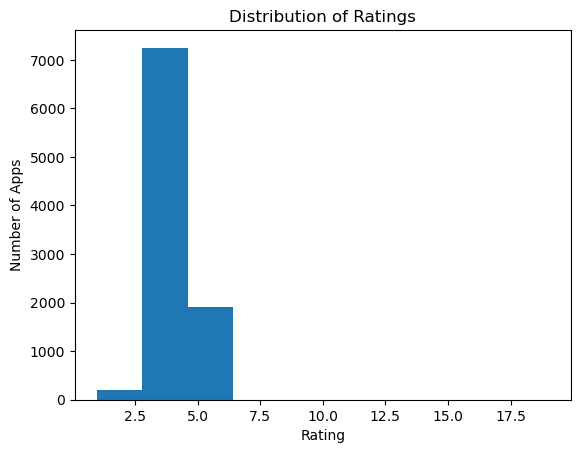

In [15]:
plt.hist(df["Rating"],bins=10)
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.title("Distribution of Ratings")
plt.show()

Write Explaination Here
.
.
.
.
.

In [ ]:
- Most apps have ratings between **4.0 and 4.5**.
- There are very few apps with ratings below **3.0**.
- The histogram shows that higher ratings are more common than lower ratings.
- This indicates that most apps on the Google Play Store are rated positively by users.

Are ratings normally distributed?

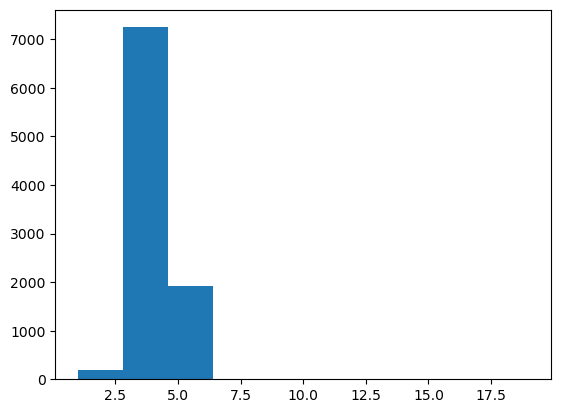

In [16]:
plt.hist(df["Rating"],bins=10)
plt.show()

Explain.....

In [ ]:
The ratings are **not normally distributed** because they do not form a bell-shaped curve.
Most apps have ratings between **4.0 and 4.5**, while only a few apps have very low ratings. The data is concentrated towards higher ratings, making the distribution **left-skewed (negatively skewed)**. This indicates that most apps on the Google Play Store receive good ratings from users.

Which rating range contains most apps?

In [17]:
rating_range=df["Rating"].value_counts(bins=5)
print(rating_range)

(0.981, 4.6]    8272
(4.6, 8.2]      1094
(15.4, 19.0]       1
(8.2, 11.8]        0
(11.8, 15.4]       0
Name: count, dtype: int64


What is the average app size?

In [18]:
average_size=df["Size"].mean()
print("Average App Size:",average_size)

Average App Size: 31.244381918819187


How are app sizes distributed?

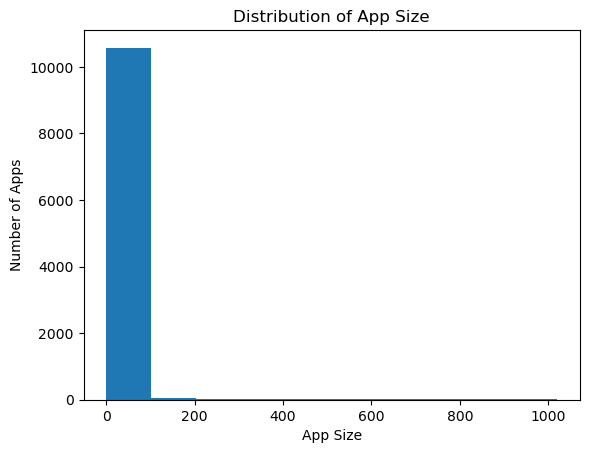

In [19]:
plt.hist(df["Size"],bins=10)
plt.xlabel("App Size")
plt.ylabel("Number of Apps")
plt.title("Distribution of App Size")
plt.show()

In [ ]:
Explain....

In [ ]:
The histogram shows that most apps have **small or medium sizes**, while only a few apps are very large. The distribution is **not uniform**, as the number of apps decreases as the app size increases. This indicates that most developers prefer to keep their apps smaller so they use less storage space on users' devices.

Which content rating category is most common?

In [20]:
content=df["Content Rating"].value_counts()
print(content)
print("\nMost Common Content Rating:",content.idxmax())

Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64

Most Common Content Rating: Everyone


What percentage of apps are free?

In [21]:
free_apps=(df["Type"]=="Free").sum()
total_apps=len(df)
percentage=(free_apps/total_apps)*100
print("Percentage of Free Apps:",percentage)

Percentage of Free Apps: 92.60215847246563


What percentage are paid?

In [22]:
paid_apps=(df["Type"]=="Paid").sum()
total_apps=len(df)
percentage=(paid_apps/total_apps)*100
print("Percentage of Paid Apps:",percentage)

Percentage of Paid Apps: 7.379393044922056


What is the maximum price of an app?

In [23]:
max_price=df["Price"].max()
print("Maximum App Price:",max_price)

Maximum App Price: 400.0


Which category contains the largest number of apps?

In [24]:
category_count=df["Category"].value_counts()
print(category_count)
print("\nCategory with the largest number of apps:",category_count.idxmax())

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

Category wit

Which category contains the fewest apps?

In [25]:
category_count=df["Category"].value_counts()
print(category_count)
print("\nCategory with the fewest apps:",category_count.idxmin())

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

Category wit

Which category has the highest average rating?

In [26]:
avg_rating=df.groupby("Category")["Rating"].mean()
print(avg_rating.sort_values(ascending=False))
print("\nCategory with Highest Average Rating:",avg_rating.idxmax())

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
PERSONALIZATION         4.335987
PARENTING               4.300000
GAME                    4.286326
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.277104
SHOPPING                4.259664
SOCIAL                  4.255598
WEATHER                 4.244000
SPORTS                  4.223511
PRODUCTIVITY            4.211396
HOUSE_AND_HOME          4.197368
FAMILY                  4.192272
PHOTOGRAPHY             4.192114
AUTO_AND_VEHICLES       4.190411
MEDICAL                 4.189143
LIBRARIES_AND_DEMO      4.178462
FOOD_AND_DRINK          4.166972
COMMUNICATION           4.158537
COMICS                  4.155172
NEWS_AND_MAGAZINES      4.132189
FINANCE                 4.131889
ENTERTAINMENT           4.126174
BUSINESS                4.121452
TRAVEL_AND_LOCAL        4.109292
LIFESTYLE               4.094904
V

Which category has the lowest average rating?

In [27]:
avg_rating=df.groupby("Category")["Rating"].mean()
print(avg_rating.sort_values())
print("\nCategory with Lowest Average Rating:",avg_rating.idxmin())

Category
DATING                  3.970769
TOOLS                   4.047411
MAPS_AND_NAVIGATION     4.051613
VIDEO_PLAYERS           4.063750
LIFESTYLE               4.094904
TRAVEL_AND_LOCAL        4.109292
BUSINESS                4.121452
ENTERTAINMENT           4.126174
FINANCE                 4.131889
NEWS_AND_MAGAZINES      4.132189
COMICS                  4.155172
COMMUNICATION           4.158537
FOOD_AND_DRINK          4.166972
LIBRARIES_AND_DEMO      4.178462
MEDICAL                 4.189143
AUTO_AND_VEHICLES       4.190411
PHOTOGRAPHY             4.192114
FAMILY                  4.192272
HOUSE_AND_HOME          4.197368
PRODUCTIVITY            4.211396
SPORTS                  4.223511
WEATHER                 4.244000
SOCIAL                  4.255598
SHOPPING                4.259664
HEALTH_AND_FITNESS      4.277104
BEAUTY                  4.278571
GAME                    4.286326
PARENTING               4.300000
PERSONALIZATION         4.335987
BOOKS_AND_REFERENCE     4.346067
A

Which category receives the highest total number of reviews?

In [28]:
total_reviews=df.groupby("Category")["Reviews"].sum()
print(total_reviews.sort_values(ascending=False))
print("\nCategory with Highest Total Reviews:",total_reviews.idxmax())

Category
GAME                   1.585422e+09
COMMUNICATION          8.154623e+08
SOCIAL                 6.212414e+08
FAMILY                 4.102263e+08
TOOLS                  2.731850e+08
PHOTOGRAPHY            2.135166e+08
SHOPPING               1.150412e+08
PRODUCTIVITY           1.141170e+08
VIDEO_PLAYERS          1.103802e+08
PERSONALIZATION        8.934614e+07
SPORTS                 7.083017e+07
TRAVEL_AND_LOCAL       6.261792e+07
ENTERTAINMENT          5.917815e+07
NEWS_AND_MAGAZINES     5.440086e+07
EDUCATION              3.959579e+07
HEALTH_AND_FITNESS     3.789374e+07
MAPS_AND_NAVIGATION    3.065925e+07
BOOKS_AND_REFERENCE    2.195907e+07
FINANCE                1.755073e+07
WEATHER                1.460474e+07
BUSINESS               1.395455e+07
LIFESTYLE              1.288278e+07
FOOD_AND_DRINK         8.883330e+06
DATING                 7.291278e+06
HOUSE_AND_HOME         3.976385e+06
COMICS                 3.383276e+06
ART_AND_DESIGN         1.714440e+06
MEDICAL            

Which category has the highest average installs?

In [29]:
avg_installs=df.groupby("Category")["Installs"].mean()
print(avg_installs.sort_values(ascending=False))
print("\nCategory with Highest Average Installs:",avg_installs.idxmax())

Category
COMMUNICATION          8.435989e+07
SOCIAL                 4.769447e+07
VIDEO_PLAYERS          3.555430e+07
PRODUCTIVITY           3.343418e+07
GAME                   3.066960e+07
PHOTOGRAPHY            3.011417e+07
TRAVEL_AND_LOCAL       2.662359e+07
NEWS_AND_MAGAZINES     2.648876e+07
ENTERTAINMENT          1.925611e+07
TOOLS                  1.358573e+07
SHOPPING               1.249173e+07
BOOKS_AND_REFERENCE    8.318050e+06
PERSONALIZATION        5.932385e+06
EDUCATION              5.586231e+06
MAPS_AND_NAVIGATION    5.286729e+06
FAMILY                 5.201959e+06
WEATHER                5.196348e+06
HEALTH_AND_FITNESS     4.642441e+06
SPORTS                 4.560350e+06
FINANCE                2.395215e+06
BUSINESS               2.178076e+06
FOOD_AND_DRINK         2.156683e+06
HOUSE_AND_HOME         1.917187e+06
ART_AND_DESIGN         1.912894e+06
LIFESTYLE              1.407444e+06
DATING                 1.129533e+06
COMICS                 9.347692e+05
LIBRARIES_AND_DEMO 

Which category has the largest app sizes?

In [30]:
avg_size=df.groupby("Category")["Size"].mean()
print(avg_size.sort_values(ascending=False))
print("\nCategory with Largest App Sizes:",avg_size.idxmax())

Category
LIBRARIES_AND_DEMO     174.451765
TOOLS                   41.882681
MEDICAL                 41.708855
GAME                    40.633042
PERSONALIZATION         38.629337
COMMUNICATION           38.200258
FAMILY                  35.309381
BOOKS_AND_REFERENCE     34.410823
AUTO_AND_VEHICLES       30.443529
HEALTH_AND_FITNESS      29.557185
COMICS                  28.995000
LIFESTYLE               28.237173
SPORTS                  26.301823
PRODUCTIVITY            25.461085
MAPS_AND_NAVIGATION     24.684672
SHOPPING                24.650385
FINANCE                 24.236885
BUSINESS                23.150000
EDUCATION               21.722436
PARENTING               20.261667
HOUSE_AND_HOME          19.794318
TRAVEL_AND_LOCAL        19.365891
SOCIAL                  18.658983
EVENTS                  17.650000
FOOD_AND_DRINK          17.468504
VIDEO_PLAYERS           16.493143
WEATHER                 16.213415
PHOTOGRAPHY             16.111642
DATING                  15.139316
ENTER

Which category contains the most paid apps?

In [31]:
paid_apps=df[df["Type"]=="Paid"]
paid_category=paid_apps["Category"].value_counts()
print(paid_category)
print("\nCategory with Most Paid Apps:",paid_category.idxmax())

Category
FAMILY                 191
MEDICAL                109
PERSONALIZATION         83
GAME                    83
TOOLS                   78
PRODUCTIVITY            28
BOOKS_AND_REFERENCE     28
COMMUNICATION           27
SPORTS                  24
PHOTOGRAPHY             22
LIFESTYLE               19
FINANCE                 17
HEALTH_AND_FITNESS      16
BUSINESS                14
TRAVEL_AND_LOCAL        12
WEATHER                  8
DATING                   7
MAPS_AND_NAVIGATION      5
EDUCATION                4
VIDEO_PLAYERS            4
SOCIAL                   3
ART_AND_DESIGN           3
AUTO_AND_VEHICLES        3
FOOD_AND_DRINK           2
ENTERTAINMENT            2
NEWS_AND_MAGAZINES       2
SHOPPING                 2
PARENTING                2
LIBRARIES_AND_DEMO       1
EVENTS                   1
Name: count, dtype: int64

Category with Most Paid Apps: FAMILY


Which category contains the highest percentage of free apps?

In [32]:
free_percentage=(df[df["Type"]=="Free"].groupby("Category").size()/df.groupby("Category").size())*100
print(free_percentage.sort_values(ascending=False))
print("\nCategory with Highest Percentage of Free Apps:",free_percentage.idxmax())

Category
BEAUTY                 100.000000
HOUSE_AND_HOME         100.000000
COMICS                 100.000000
NEWS_AND_MAGAZINES      99.293286
SHOPPING                99.230769
SOCIAL                  98.983051
LIBRARIES_AND_DEMO      98.823529
ENTERTAINMENT           98.657718
EVENTS                  98.437500
FOOD_AND_DRINK          98.425197
VIDEO_PLAYERS           97.714286
EDUCATION               97.435897
DATING                  97.008547
BUSINESS                96.956522
PARENTING               96.666667
AUTO_AND_VEHICLES       96.470588
MAPS_AND_NAVIGATION     96.350365
ART_AND_DESIGN          95.384615
FINANCE                 95.355191
TRAVEL_AND_LOCAL        95.348837
HEALTH_AND_FITNESS      95.307918
LIFESTYLE               95.026178
SPORTS                  93.750000
PHOTOGRAPHY             93.432836
PRODUCTIVITY            93.396226
COMMUNICATION           93.023256
GAME                    92.744755
TOOLS                   90.747331
FAMILY                  90.263692
WEATH

Are certain categories dominated by a single content rating?

In [33]:
content_rating=df.groupby("Category")["Content Rating"].value_counts()
print(content_rating)

Category           Content Rating
ART_AND_DESIGN     Everyone          61
                   Teen               3
                   Everyone 10+       1
AUTO_AND_VEHICLES  Everyone          83
                   Everyone 10+       1
                                     ..
VIDEO_PLAYERS      Everyone 10+       2
WEATHER            Everyone          78
                   Teen               2
                   Everyone 10+       1
                   Mature 17+         1
Name: count, Length: 118, dtype: int64


What are the top 20 highest-rated apps?

In [34]:
top20=df.sort_values(by="Rating",ascending=False)[["App","Category","Rating"]].head(20)
print(top20)

                                            App            Category  Rating
10472   Life Made WI-Fi Touchscreen Photo Frame                 1.9    19.0
7895                 Dine In CT - Food Delivery            SHOPPING     5.0
7731                                    CQ ESPM            BUSINESS     5.0
7754                                  CricQuick              SPORTS     5.0
10837          Fr. Mike Schmitz Audio Teachings              FAMILY     5.0
10611                Beacon Baptist Jupiter, FL           LIFESTYLE     5.0
10621               Florida Beach Wallpapers HD    TRAVEL_AND_LOCAL     5.0
10629                       Florida Wildflowers              FAMILY     5.0
1547                               Eternal life  LIBRARIES_AND_DEMO     5.0
2262   Super Hearing Secret Voices Recorder PRO             MEDICAL     5.0
2271                             FHR 5-Tier 2.0             MEDICAL     5.0
1038                  Mindvalley U Tallinn 2018              EVENTS     5.0
1028        

Which category contributes most of the 5-star apps?

In [35]:
five_star=df[df["Rating"]==5.0]
five_star_category=five_star["Category"].value_counts()
print(five_star_category)
print("\nCategory with Most 5-Star Apps:",five_star_category.idxmax())

Category
FAMILY                 67
LIFESTYLE              29
MEDICAL                28
BUSINESS               18
TOOLS                  17
HEALTH_AND_FITNESS     12
GAME                   12
PERSONALIZATION        10
FINANCE                 8
SOCIAL                  8
PRODUCTIVITY            8
NEWS_AND_MAGAZINES      7
PHOTOGRAPHY             6
DATING                  6
SHOPPING                6
EVENTS                  6
BOOKS_AND_REFERENCE     6
COMMUNICATION           5
SPORTS                  4
TRAVEL_AND_LOCAL        3
COMICS                  2
LIBRARIES_AND_DEMO      2
FOOD_AND_DRINK          2
PARENTING               1
ART_AND_DESIGN          1
Name: count, dtype: int64

Category with Most 5-Star Apps: FAMILY


Do apps with more reviews receive higher ratings?

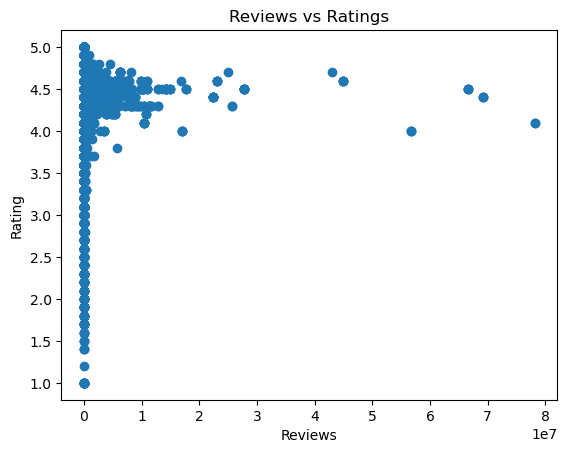

In [36]:
plt.scatter(df["Reviews"],df["Rating"])
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Ratings")
plt.show()

Do highly installed apps have better ratings?

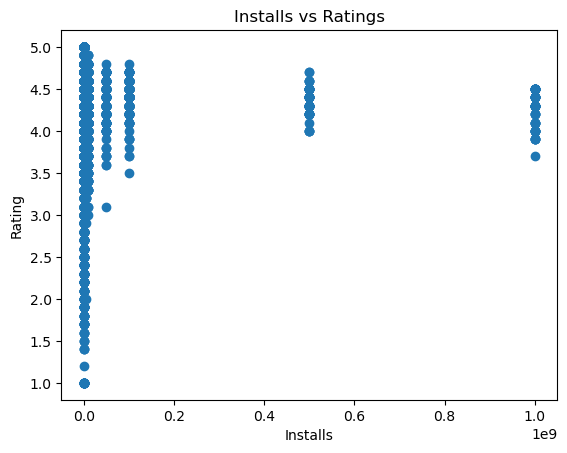

In [37]:
plt.scatter(df["Installs"],df["Rating"])
plt.xlabel("Installs")
plt.ylabel("Rating")
plt.title("Installs vs Ratings")
plt.show()

Which category has the greatest variation in ratings?

In [38]:
rating_variation=df.groupby("Category")["Rating"].std()
print(rating_variation.sort_values(ascending=False))
print("\nCategory with Greatest Variation in Ratings:",rating_variation.idxmax())

Category
LIFESTYLE              0.693907
MEDICAL                0.663581
FINANCE                0.642108
DATING                 0.630510
BUSINESS               0.624422
HEALTH_AND_FITNESS     0.617822
TOOLS                  0.616143
VIDEO_PLAYERS          0.551098
FOOD_AND_DRINK         0.548070
AUTO_AND_VEHICLES      0.543692
COMICS                 0.537758
NEWS_AND_MAGAZINES     0.536707
MAPS_AND_NAVIGATION    0.519926
PARENTING              0.517845
FAMILY                 0.508026
PRODUCTIVITY           0.504931
TRAVEL_AND_LOCAL       0.504691
PHOTOGRAPHY            0.462896
BOOKS_AND_REFERENCE    0.429046
SPORTS                 0.427857
COMMUNICATION          0.426192
EVENTS                 0.419499
SOCIAL                 0.413809
SHOPPING               0.404577
LIBRARIES_AND_DEMO     0.378522
HOUSE_AND_HOME         0.368411
GAME                   0.365375
BEAUTY                 0.362603
ART_AND_DESIGN         0.358297
PERSONALIZATION        0.352732
WEATHER                0.331353

Are ratings different between free and paid apps?

In [39]:
rating_type=df.groupby("Type")["Rating"].mean()
print(rating_type)

Type
0       19.000000
Free     4.186203
Paid     4.266615
Name: Rating, dtype: float64


Which apps have the highest installs?

In [40]:
top_installs=df.sort_values(by="Installs",ascending=False)[["App","Category","Installs"]].head(20)
print(top_installs)

                                App          Category      Installs
2808                  Google Photos       PHOTOGRAPHY  1.000000e+09
2853                  Google Photos       PHOTOGRAPHY  1.000000e+09
3223      Maps - Navigate & Explore  TRAVEL_AND_LOCAL  1.000000e+09
3117      Maps - Navigate & Explore  TRAVEL_AND_LOCAL  1.000000e+09
3234                         Google             TOOLS  1.000000e+09
3232             Google Street View  TRAVEL_AND_LOCAL  1.000000e+09
3127             Google Street View  TRAVEL_AND_LOCAL  1.000000e+09
2554                        Google+            SOCIAL  1.000000e+09
464                        Hangouts     COMMUNICATION  1.000000e+09
468   Skype - free IM & video calls     COMMUNICATION  1.000000e+09
451                           Gmail     COMMUNICATION  1.000000e+09
391   Skype - free IM & video calls     COMMUNICATION  1.000000e+09
386                        Hangouts     COMMUNICATION  1.000000e+09
3454                   Google Drive      PRODUCT

Do larger apps tend to have higher ratings?

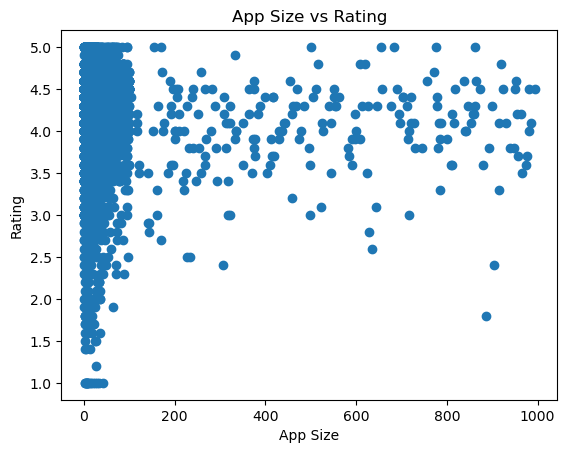

In [41]:
plt.scatter(df["Size"],df["Rating"])
plt.xlabel("App Size")
plt.ylabel("Rating")
plt.title("App Size vs Rating")
plt.show()


Are older apps rated differently than recently updated apps?

In [43]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")
df["Year"] = df["Last Updated"].dt.year

rating_year = (
    df.groupby("Year", as_index=False)["Rating"]
    .mean()
    .sort_values("Year")
)

Which category has the most consistent ratings?

In [45]:
category_consistency = df.groupby("Category")["Rating"].std().sort_values()
category_consistency

Category
EDUCATION              0.251894
ENTERTAINMENT          0.302556
WEATHER                0.331353
PERSONALIZATION        0.352732
ART_AND_DESIGN         0.358297
BEAUTY                 0.362603
GAME                   0.365375
HOUSE_AND_HOME         0.368411
LIBRARIES_AND_DEMO     0.378522
SHOPPING               0.404577
SOCIAL                 0.413809
EVENTS                 0.419499
COMMUNICATION          0.426192
SPORTS                 0.427857
BOOKS_AND_REFERENCE    0.429046
PHOTOGRAPHY            0.462896
TRAVEL_AND_LOCAL       0.504691
PRODUCTIVITY           0.504931
FAMILY                 0.508026
PARENTING              0.517845
MAPS_AND_NAVIGATION    0.519926
NEWS_AND_MAGAZINES     0.536707
COMICS                 0.537758
AUTO_AND_VEHICLES      0.543692
FOOD_AND_DRINK         0.548070
VIDEO_PLAYERS          0.551098
TOOLS                  0.616143
HEALTH_AND_FITNESS     0.617822
BUSINESS               0.624422
DATING                 0.630510
FINANCE                0.642108

Which category contributes the highest total installs?

In [49]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
    .astype(float)
)
category_installs = df.groupby("Category")["Installs"].sum().sort_values(ascending=False)
category_installs
top_category = category_installs.idxmax()
top_value = category_installs.max()

print(top_category, top_value)
category_installs.head(10)

GAME 35086024415.0


Category
GAME                  3.508602e+10
COMMUNICATION         3.264728e+10
PRODUCTIVITY          1.417609e+10
SOCIAL                1.406987e+10
TOOLS                 1.145277e+10
FAMILY                1.025826e+10
PHOTOGRAPHY           1.008825e+10
NEWS_AND_MAGAZINES    7.496318e+09
TRAVEL_AND_LOCAL      6.868887e+09
VIDEO_PLAYERS         6.222003e+09
Name: Installs, dtype: float64

What is the relationship between reviews and ratings?


Yearly Average Rating:
Year
2012.0    3.785714
2011.0    3.966667
2014.0    4.037895
2016.0    4.041782
2015.0    4.067268
2013.0    4.073404
2017.0    4.094793
2010.0    4.200000
2018.0    4.244530
Name: Rating, dtype: float64

Top Category by Installs:
Category
GAME                  3.508602e+10
COMMUNICATION         3.264728e+10
PRODUCTIVITY          1.417609e+10
SOCIAL                1.406987e+10
TOOLS                 1.145277e+10
FAMILY                1.025826e+10
PHOTOGRAPHY           1.008825e+10
NEWS_AND_MAGAZINES    7.496318e+09
TRAVEL_AND_LOCAL      6.868887e+09
VIDEO_PLAYERS         6.222003e+09
Name: Installs, dtype: float64

Most Consistent Category:
Category
EDUCATION             0.251894
ENTERTAINMENT         0.302556
WEATHER               0.331353
PERSONALIZATION       0.352732
ART_AND_DESIGN        0.358297
BEAUTY                0.362603
GAME                  0.365375
HOUSE_AND_HOME        0.368411
LIBRARIES_AND_DEMO    0.378522
SHOPPING              0.404577
Name: Ra

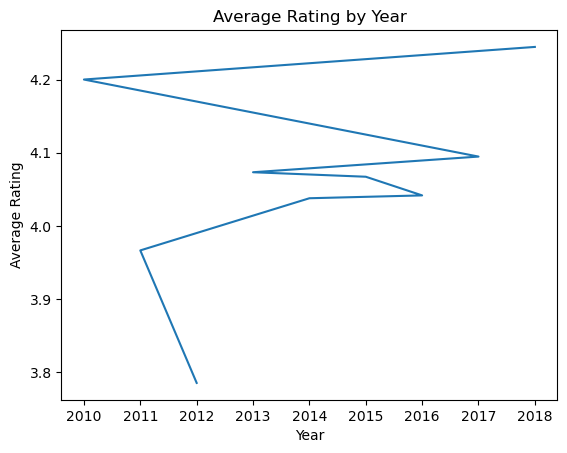

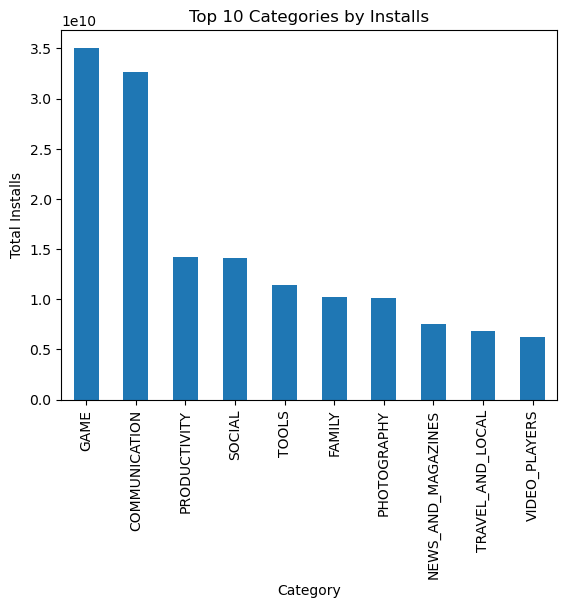

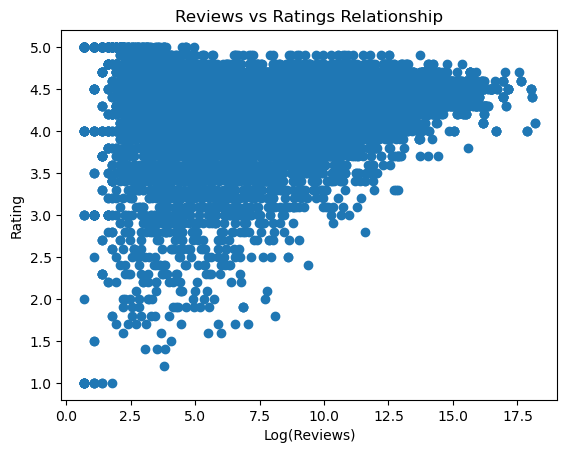

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. DATA CLEANING

df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")
df["Year"] = df["Last Updated"].dt.year

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# 2. YEARLY AVERAGE RATING
rating_year = df.groupby("Year")["Rating"].mean().sort_values()

print("\nYearly Average Rating:")
print(rating_year)


# 3. CATEGORY: TOTAL INSTALLS

category_installs = df.groupby("Category")["Installs"].sum().sort_values(ascending=False)

print("\nTop Category by Installs:")
print(category_installs.head(10))

# 4. CATEGORY: RATING CONSISTENCY
category_consistency = df.groupby("Category")["Rating"].std().sort_values()

print("\nMost Consistent Category:")
print(category_consistency.head(10))

# 5. REVIEWS vs RATINGS RELATIONSHIP

corr = df["Reviews"].corr(df["Rating"])
print("\nCorrelation (Reviews vs Ratings):", corr)

# 6. VISUALIZATIONS

# (A) Yearly rating trend
plt.figure()
plt.plot(rating_year.index, rating_year.values)
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average Rating by Year")
plt.show()


# (B) Top categories by installs
plt.figure()
category_installs.head(10).plot(kind="bar")
plt.ylabel("Total Installs")
plt.title("Top 10 Categories by Installs")
plt.show()


# (C) Reviews vs Ratings
plt.figure()
plt.scatter(np.log1p(df["Reviews"]), df["Rating"])
plt.xlabel("Log(Reviews)")
plt.ylabel("Rating")
plt.title("Reviews vs Ratings Relationship")
plt.show()

Do paid apps receive fewer installs than free apps?

Type
Free    1.669095e+07
Paid    9.119510e+04
0                NaN
Name: Installs, dtype: float64
Type
0       0.000000e+00
Free    1.675605e+11
Paid    7.295608e+07
Name: Installs, dtype: float64


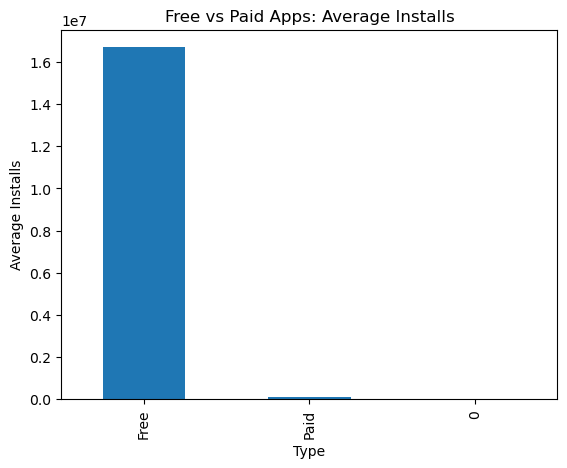

In [52]:
df["Installs"] = df["Installs"].astype(float)

installs_by_type = df.groupby("Type")["Installs"].mean().sort_values(ascending=False)
print(installs_by_type)
total_installs = df.groupby("Type")["Installs"].sum()
print(total_installs)
import matplotlib.pyplot as plt

installs_by_type.plot(kind="bar")
plt.ylabel("Average Installs")
plt.title("Free vs Paid Apps: Average Installs")
plt.show()

What percentage of apps have fewer than 10,000 installs?

In [53]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")
low_installs_count = (df["Installs"] < 10000).sum()
total_apps = df["Installs"].notna().sum()
percentage = (low_installs_count / total_apps) * 100
print("Percentage of apps with <10,000 installs:", percentage)

Percentage of apps with <10,000 installs: 29.40959409594096


Are highly-rated apps downloaded more frequently?

Correlation (Rating vs Installs): 0.05135456605599933


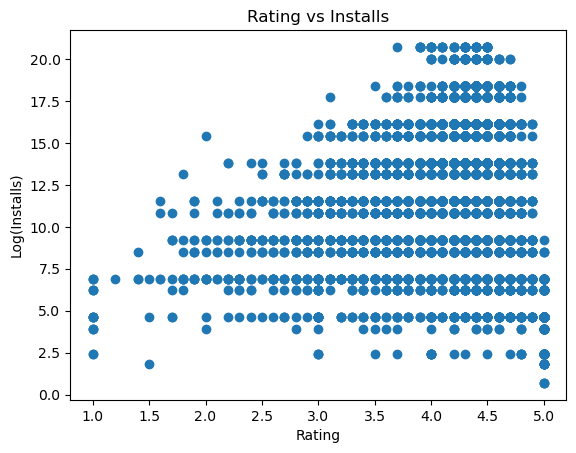

In [54]:
df["Installs"] = df["Installs"].astype(float)
df["Rating"] = df["Rating"].astype(float)

corr = df["Rating"].corr(df["Installs"])
print("Correlation (Rating vs Installs):", corr)
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(df["Rating"], np.log1p(df["Installs"]))
plt.xlabel("Rating")
plt.ylabel("Log(Installs)")
plt.title("Rating vs Installs")
plt.show()

Which content-rating group has the highest installs?

Content Rating
Everyone           1.141567e+11
Teen               3.471635e+10
Everyone 10+       1.323388e+10
Mature 17+         5.524491e+09
Adults only 18+    2.000000e+06
Unrated            5.050000e+04
Name: Installs, dtype: float64
Highest installs group: Everyone
Total installs: 114156659621.0


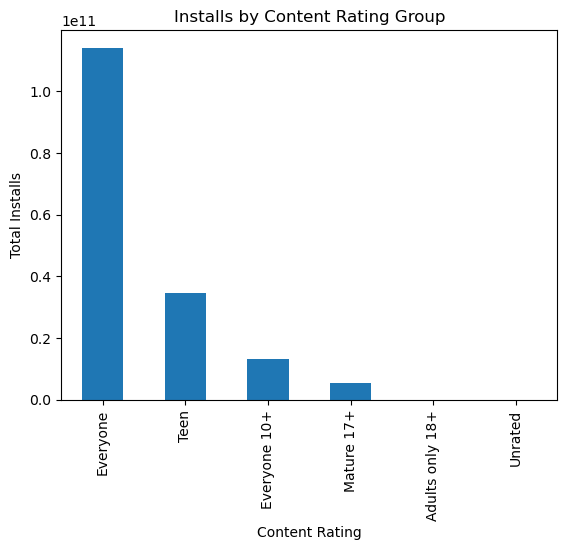

In [55]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

content_installs = df.groupby("Content Rating")["Installs"].sum().sort_values(ascending=False)
print(content_installs)

top_group = content_installs.idxmax()
top_value = content_installs.max()

print("Highest installs group:", top_group)
print("Total installs:", top_value)

import matplotlib.pyplot as plt

content_installs.plot(kind="bar")
plt.ylabel("Total Installs")
plt.title("Installs by Content Rating Group")
plt.show()

Which category contains the greatest number of apps with over 1 million installs?

Category
GAME                   737
FAMILY                 651
TOOLS                  289
PHOTOGRAPHY            226
COMMUNICATION          212
PRODUCTIVITY           197
SPORTS                 174
SHOPPING               161
SOCIAL                 156
HEALTH_AND_FITNESS     156
ENTERTAINMENT          132
TRAVEL_AND_LOCAL       132
PERSONALIZATION        126
NEWS_AND_MAGAZINES     112
FINANCE                111
EDUCATION              108
BUSINESS                97
VIDEO_PLAYERS           95
LIFESTYLE               89
FOOD_AND_DRINK          63
BOOKS_AND_REFERENCE     61
MAPS_AND_NAVIGATION     60
DATING                  58
WEATHER                 45
HOUSE_AND_HOME          43
MEDICAL                 26
COMICS                  18
AUTO_AND_VEHICLES       18
PARENTING               15
LIBRARIES_AND_DEMO      14
ART_AND_DESIGN          13
BEAUTY                  10
EVENTS                   6
Name: Installs, dtype: int64
GAME 737


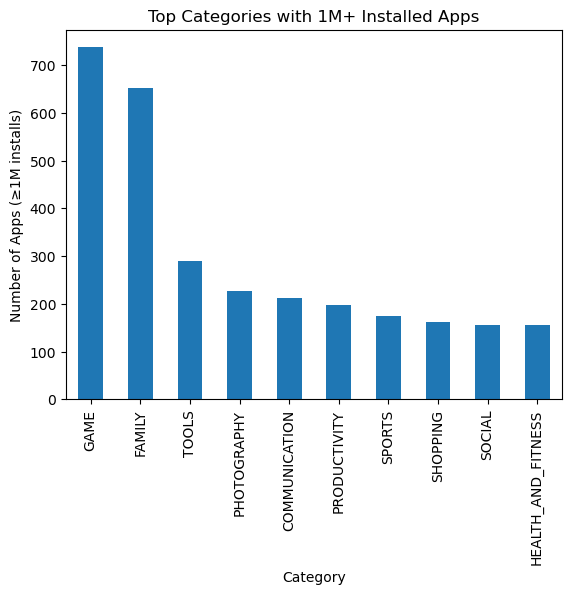

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df_1m = df[df["Installs"] >= 1_000_000]

category_counts = (
    df_1m.groupby("Category")["Installs"]
    .count()
    .sort_values(ascending=False)
)

print(category_counts)

top_category = category_counts.idxmax()
top_value = category_counts.max()

print(top_category, top_value)

plt.figure()
category_counts.head(10).plot(kind="bar")
plt.ylabel("Number of Apps (≥1M installs)")
plt.title("Top Categories with 1M+ Installed Apps")
plt.show()

Are installs concentrated among a few apps?

Top 10 apps contribute (%): 5.965397112011967
Top 1% apps contribute (%): 49.51279602969933


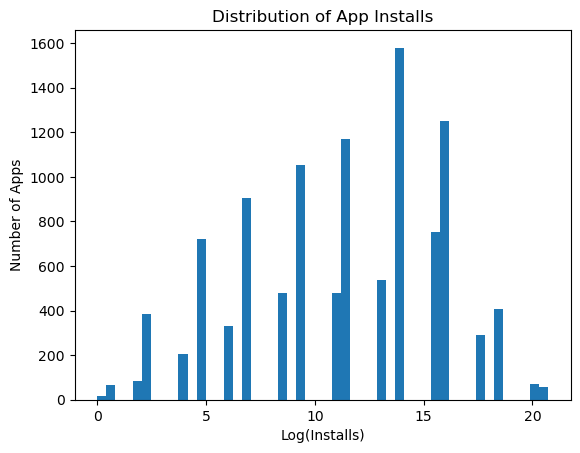

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

sorted_df = df.sort_values("Installs", ascending=False)

top10_installs = sorted_df.head(10)["Installs"].sum()
total_installs = sorted_df["Installs"].sum()
share_top10 = (top10_installs / total_installs) * 100

top_1_percent = int(0.01 * len(sorted_df))
top1_installs = sorted_df.head(top_1_percent)["Installs"].sum()
share_top1 = (top1_installs / total_installs) * 100

print("Top 10 apps contribute (%):", share_top10)
print("Top 1% apps contribute (%):", share_top1)

plt.figure()
plt.hist(np.log1p(df["Installs"]), bins=50)
plt.xlabel("Log(Installs)")
plt.ylabel("Number of Apps")
plt.title("Distribution of App Installs")
plt.show()

What is the average price of paid apps?

In [58]:
import pandas as pd

df["Price"] = df["Price"].astype(str).str.replace("$", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

paid_apps = df[df["Type"] == "Paid"]

avg_price = paid_apps["Price"].mean()

print("Average price of paid apps:", avg_price)

Average price of paid apps: 13.920837500000003


Which category has the most expensive apps?

In [59]:
import pandas as pd

df["Price"] = df["Price"].astype(str).str.replace("$", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

category_price_mean = df.groupby("Category")["Price"].mean().sort_values(ascending=False)

category_price_max = df.groupby("Category")["Price"].max().sort_values(ascending=False)

print("Highest average price category:")
print(category_price_mean.head(10))

print("\nHighest max price category:")
print(category_price_max.head(10))

top_avg_category = category_price_mean.idxmax()
top_avg_value = category_price_mean.max()

print("\nCategory with highest average price:", top_avg_category, top_avg_value)

Highest average price category:
Category
FINANCE                7.925765
LIFESTYLE              6.180288
MEDICAL                3.110065
EVENTS                 1.718594
FAMILY                 1.234675
PRODUCTIVITY           0.591816
BOOKS_AND_REFERENCE    0.518485
BUSINESS               0.402761
PHOTOGRAPHY            0.400627
WEATHER                0.395366
Name: Price, dtype: float64

Highest max price category:
Category
LIFESTYLE       400.00
FINANCE         399.99
FAMILY          399.99
MEDICAL         200.00
PRODUCTIVITY    154.99
EVENTS          109.99
BUSINESS         89.99
SPORTS           29.99
PHOTOGRAPHY      29.99
TOOLS            25.99
Name: Price, dtype: float64

Category with highest average price: FINANCE 7.925765027322404


What is the distribution of installs?

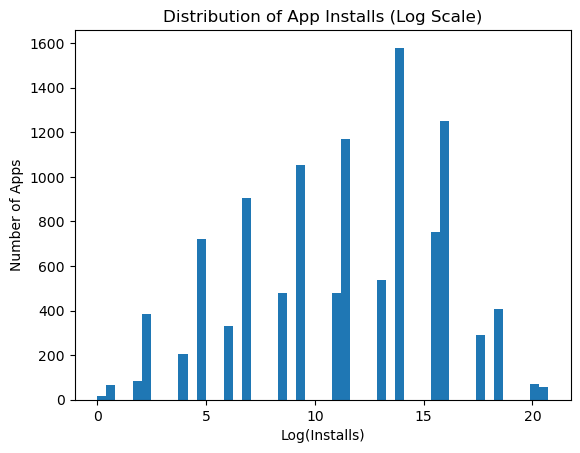

count    1.084000e+04
mean     1.546434e+07
std      8.502936e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

plt.figure()
plt.hist(np.log1p(df["Installs"]), bins=50)
plt.xlabel("Log(Installs)")
plt.ylabel("Number of Apps")
plt.title("Distribution of App Installs (Log Scale)")
plt.show()

print(df["Installs"].describe())

Which genre contains the largest number of apps?

In [61]:
import pandas as pd

genre_counts = df["Genres"].value_counts()

print(genre_counts.head(10))

top_genre = genre_counts.idxmax()
top_value = genre_counts.max()

print("Top genre:", top_genre)
print("Number of apps:", top_value)

Genres
Tools              842
Entertainment      623
Education          549
Medical            463
Business           460
Productivity       424
Sports             398
Personalization    392
Communication      387
Lifestyle          381
Name: count, dtype: int64
Top genre: Tools
Number of apps: 842


In [ ]:
Does higher price imply higher ratings?

Correlation between Price and Rating: -0.02190330080135546


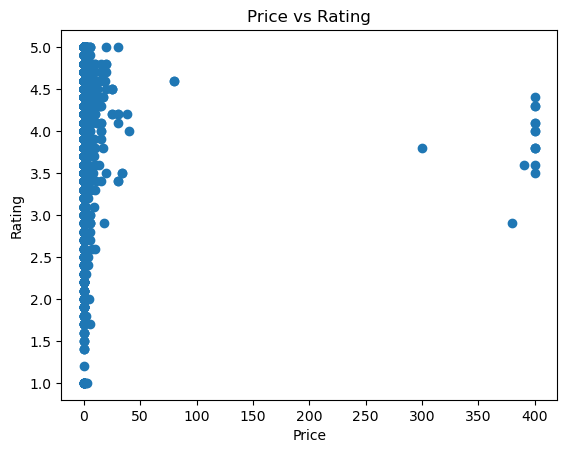

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

df["Price"] = df["Price"].astype(str).str.replace("$", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

corr = df["Price"].corr(df["Rating"])
print("Correlation between Price and Rating:", corr)

plt.figure()
plt.scatter(df["Price"], df["Rating"])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

Which app is the most expensive?

In [63]:


df["Price"] = df["Price"].astype(str).str.replace("$", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

max_price = df["Price"].max()

most_expensive_app = df[df["Price"] == max_price][["App", "Category", "Price"]]

print(most_expensive_app)

                           App   Category  Price
4367  I'm Rich - Trump Edition  LIFESTYLE  400.0


Which category generates the highest total revenue potential?

In [65]:
df["Price"] = df["Price"].astype(str).str.replace("$", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Revenue"] = df["Price"] * df["Installs"]

df_paid = df[df["Type"] == "Paid"]

category_revenue = df_paid.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

print(category_revenue)

top_category = category_revenue.idxmax()
top_value = category_revenue.max()

print(top_category, top_value)

Category
FAMILY                 1.860526e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            2.092277e+07
MEDICAL                1.357484e+07
PERSONALIZATION        1.027695e+07
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
BUSINESS               2.048543e+06
HEALTH_AND_FITNESS     1.725069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6.445000e+03
SOCIAL             

Does price affect installs?

Correlation (Price vs Installs): -0.011689470477901583


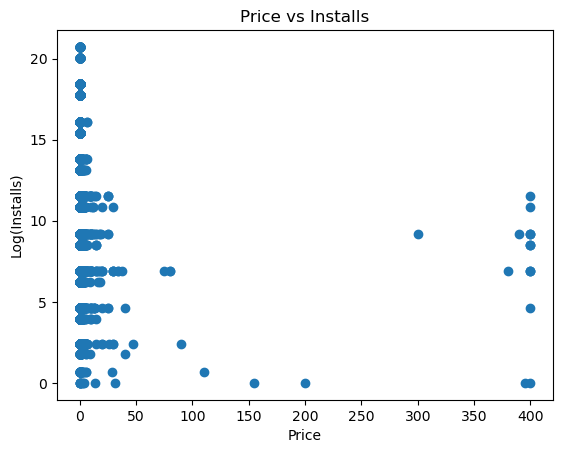

In [66]:
df["Price"] = df["Price"].astype(str).str.replace("$", "")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Installs"] = (
    df["Installs"].astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

corr = df["Price"].corr(df["Installs"])
print("Correlation (Price vs Installs):", corr)

plt.figure()
plt.scatter(df["Price"], np.log1p(df["Installs"]))
plt.xlabel("Price")
plt.ylabel("Log(Installs)")
plt.title("Price vs Installs")
plt.show()

What percentage of apps cost more than $10? and Figure out some other pricing ranges?

In [68]:
total_apps = len(df)

above_10 = len(df[df["Price"] > 10])

percentage_above_10 = (above_10 / total_apps) * 100

print(percentage_above_10)
bins = [0, 0.01, 2, 5, 10, float("inf")]
labels = ["Free", "Low", "Mid", "High", "Premium"]

df["price_category"] = pd.cut(df["Price"], bins=bins, labels=labels, include_lowest=True)

print(df["price_category"].value_counts(normalize=True) * 100)

0.8209574762475786
price_category
Free       92.619926
Mid         3.035055
Low         2.638376
High        0.885609
Premium     0.821033
Name: proportion, dtype: float64


Is there a relationship between app size and price?

In [71]:
import numpy as np

def clean_size(x):
    if x == "Varies with device":
        return np.nan
    if "M" in x:
        return float(x.replace("M", ""))
    if "k" in x or "K" in x:
        return float(x.replace("k", "").replace("K", "")) / 1024
    if "G" in x:
        return float(x.replace("G", "")) * 1024
    return np.nan


In which year were the most apps updated?

In [72]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])
df["Update_Year"] = df["Last Updated"].dt.year
df["Update_Year"].value_counts()
df["Update_Year"].value_counts().idxmax()

np.float64(2018.0)

# Relationship Analysis
    Relationship between Reviews and Installs?



    Relationship between Price and Installs?



    Relationship between Size and Rating?



    Relationship between Reviews and Rating?



    Relationship between Size and Installs?



    Relationship between Price and Reviews?



    Relationship between App Size and Revenue Potential?

Correlation Matrix:
            Reviews  Installs     Price      Size    Rating
Reviews   1.000000  0.641612 -0.009820 -0.005510  0.068141
Installs  0.641612  1.000000 -0.011890 -0.028971  0.051355
Price    -0.009820 -0.011890  1.000000  0.021993 -0.021903
Size     -0.005510 -0.028971  0.021993  1.000000 -0.030264
Rating    0.068141  0.051355 -0.021903 -0.030264  1.000000

Reviews vs Installs:
            Reviews  Installs
Reviews   1.000000  0.641612
Installs  0.641612  1.000000

Price vs Installs:
             Price  Installs
Price     1.00000  -0.01189
Installs -0.01189   1.00000

Size vs Rating:
             Size    Rating
Size    1.000000 -0.030264
Rating -0.030264  1.000000

Reviews vs Rating:
           Reviews    Rating
Reviews  1.000000  0.068141
Rating   0.068141  1.000000

Size vs Installs:
               Size  Installs
Size      1.000000 -0.028971
Installs -0.028971  1.000000

Price vs Reviews:
            Price  Reviews
Price    1.00000 -0.00982
Reviews -0.00982  1.00000



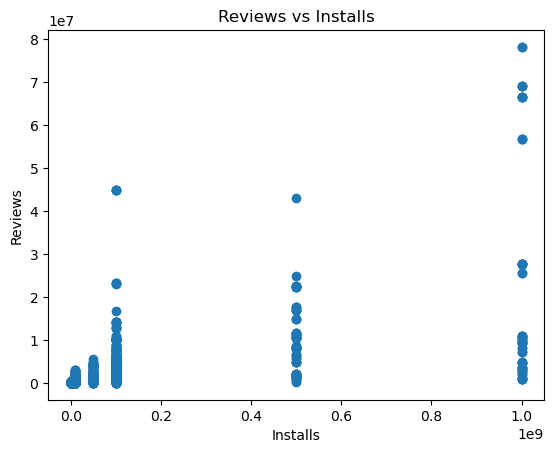

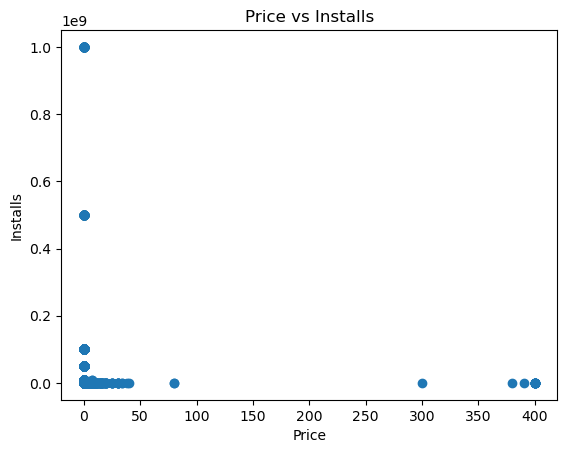

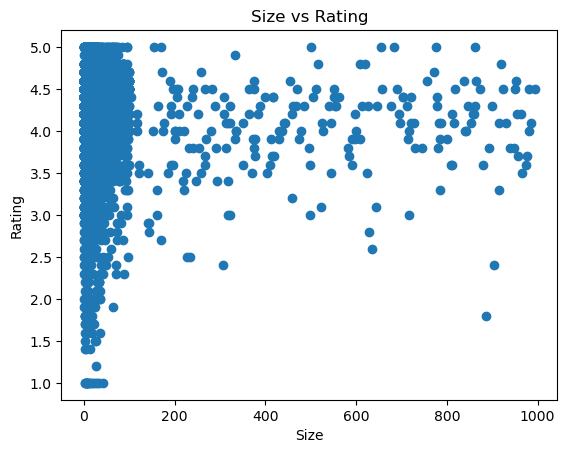

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = df.copy()

df["Installs"] = df["Installs"].astype(str).str.replace("+", "").str.replace(",", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Size"] = df["Size"].astype(str).str.replace("M", "").str.replace("k", "", regex=True)
df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df = df.dropna(subset=["Reviews", "Installs", "Price", "Size", "Rating"])

cols = ["Reviews", "Installs", "Price", "Size", "Rating"]
corr_matrix = df[cols].corr()
print("Correlation Matrix:\n", corr_matrix)

df["Revenue_Potential"] = df["Price"] * df["Installs"]

print("\nReviews vs Installs:\n", df[["Reviews", "Installs"]].corr())
print("\nPrice vs Installs:\n", df[["Price", "Installs"]].corr())
print("\nSize vs Rating:\n", df[["Size", "Rating"]].corr())
print("\nReviews vs Rating:\n", df[["Reviews", "Rating"]].corr())
print("\nSize vs Installs:\n", df[["Size", "Installs"]].corr())
print("\nPrice vs Reviews:\n", df[["Price", "Reviews"]].corr())
print("\nSize vs Revenue Potential:\n", df[["Size", "Revenue_Potential"]].corr())

plt.figure()
plt.scatter(df["Installs"], df["Reviews"])
plt.xlabel("Installs")
plt.ylabel("Reviews")
plt.title("Reviews vs Installs")
plt.show()

plt.figure()
plt.scatter(df["Price"], df["Installs"])
plt.xlabel("Price")
plt.ylabel("Installs")
plt.title("Price vs Installs")
plt.show()

plt.figure()
plt.scatter(df["Size"], df["Rating"])
plt.xlabel("Size")
plt.ylabel("Rating")
plt.title("Size vs Rating")
plt.show()

Do free and paid apps have significantly different ratings?

In [75]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

df = df.copy()

df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df = df.dropna(subset=["Price", "Rating"])

df["Type"] = np.where(df["Price"] > 0, "Paid", "Free")

print(df.groupby("Type")["Rating"].agg(["mean", "count", "std"]))

free_ratings = df[df["Type"] == "Free"]["Rating"]
paid_ratings = df[df["Type"] == "Paid"]["Rating"]

t_stat, p_value = ttest_ind(free_ratings, paid_ratings, equal_var=False)

print("\nT-statistic:", t_stat)
print("P-value:", p_value)

          mean  count       std
Type                           
Free  4.186203   8719  0.512338
Paid  4.266615    647  0.547523

T-statistic: -3.619962711026508
P-value: 0.0003149306617059253


Are Type and Content Rating independent?

In [76]:
import pandas as pd
from scipy.stats import chi2_contingency

df = df.copy()

df["Price"] = pd.to_numeric(df["Price"].astype(str).str.replace("$", "", regex=True), errors="coerce")
df["Content Rating"] = df["Content Rating"].astype(str)

df["Type"] = df["Price"].apply(lambda x: "Paid" if x > 0 else "Free")

contingency_table = pd.crosstab(df["Type"], df["Content Rating"])

print("Contingency Table:\n", contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)

print("\nExpected frequencies:\n", expected)

Contingency Table:
 Content Rating  Adults only 18+  Everyone  Everyone 10+  Mature 17+  Teen  \
Type                                                                        
Free                          3      6868           364         444  1039   
Paid                          0       552            33          17    45   

Content Rating  Unrated  
Type                     
Free                  1  
Paid                  0  

Chi-square statistic: 25.016431538101763
P-value: 0.00013831958333065952
Degrees of freedom: 5

Expected frequencies:
 [[2.79276105e+00 6.90742900e+03 3.69575379e+02 4.29154281e+02
  1.00911766e+03 9.30920350e-01]
 [2.07238949e-01 5.12571001e+02 2.74246210e+01 3.18457186e+01
  7.48823404e+01 6.90796498e-02]]


Create a Revenue Potential feature
use Revenue = Price × Installs

In [78]:


df = df.copy()

# Clean Price
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Clean Installs
df["Installs"] = df["Installs"].astype(str).str.replace("+", "").str.replace(",", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["Price", "Installs"])

# Create Revenue Potential feature
df["Revenue_Potential"] = df["Price"] * df["Installs"]

# View result
print(df[["App", "Price", "Installs", "Revenue_Potential"]].head())

# Optional: top revenue apps
print("\nTop 10 Revenue Potential Apps:\n")
print(df.sort_values("Revenue_Potential", ascending=False)[["App", "Revenue_Potential"]].head(10))

                                                 App  Price    Installs  \
0     Photo Editor & Candy Camera & Grid & ScrapBook    0.0     10000.0   
1                                Coloring book moana    0.0    500000.0   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...    0.0   5000000.0   
3                              Sketch - Draw & Paint    0.0  50000000.0   
4              Pixel Draw - Number Art Coloring Book    0.0    100000.0   

   Revenue_Potential  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                0.0  

Top 10 Revenue Potential Apps:

                                App  Revenue_Potential
2241                      Minecraft         69900000.0
4347                      Minecraft         69900000.0
5351                      I am rich         39999000.0
5356              I Am Rich Premium         19999500.0
4034                  Hitman Sniper          9900000.0
7417  Grand Theft Auto: San Andreas          699

Which category has the highest revenue potential?

In [79]:


df = df.copy()

# Ensure numeric cleanup (if not already done)
df["Price"] = pd.to_numeric(df["Price"].astype(str).str.replace("$", "", regex=True), errors="coerce")
df["Installs"] = pd.to_numeric(df["Installs"].astype(str).str.replace("+", "").str.replace(",", ""), errors="coerce")

df = df.dropna(subset=["Category", "Price", "Installs"])

# Revenue Potential
df["Revenue_Potential"] = df["Price"] * df["Installs"]

# Category-wise total revenue
category_revenue = df.groupby("Category")["Revenue_Potential"].sum().sort_values(ascending=False)

print("Top Categories by Revenue Potential:\n")
print(category_revenue.head(10))

# Highest category
print("\nHighest Revenue Category:", category_revenue.idxmax())
print("Revenue:", category_revenue.max())

Top Categories by Revenue Potential:

Category
FAMILY             1.860466e+08
LIFESTYLE          5.758394e+07
GAME               4.098684e+07
FINANCE            2.572664e+07
PHOTOGRAPHY        2.092105e+07
MEDICAL            1.348716e+07
PERSONALIZATION    1.027631e+07
TOOLS              5.462910e+06
SPORTS             4.706154e+06
PRODUCTIVITY       4.304452e+06
Name: Revenue_Potential, dtype: float64

Highest Revenue Category: FAMILY
Revenue: 186046586.70000002


Create a Review-to-Install Ratio:

Review_Ratio = Reviews / Installs



In [80]:


df = df.copy()

# Clean Installs
df["Installs"] = df["Installs"].astype(str).str.replace("+", "").str.replace(",", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Clean Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Remove invalid rows
df = df.dropna(subset=["Reviews", "Installs"])

# Create Review-to-Install Ratio
df["Review_Ratio"] = df["Reviews"] / df["Installs"]

# View result
print(df[["App", "Reviews", "Installs", "Review_Ratio"]].head())

# Top apps by engagement (highest ratios)
print("\nTop 10 Apps by Review Ratio:\n")
print(df.sort_values("Review_Ratio", ascending=False)[["App", "Review_Ratio"]].head(10))

                                                 App   Reviews    Installs  \
0     Photo Editor & Candy Camera & Grid & ScrapBook     159.0     10000.0   
1                                Coloring book moana     967.0    500000.0   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...   87510.0   5000000.0   
3                              Sketch - Draw & Paint  215644.0  50000000.0   
4              Pixel Draw - Number Art Coloring Book     967.0    100000.0   

   Review_Ratio  
0      0.015900  
1      0.001934  
2      0.017502  
3      0.004313  
4      0.009670  

Top 10 Apps by Review Ratio:

                                 App  Review_Ratio
2454             KBA-EZ Health Guide        4.0000
8591                         DN Blog        2.0000
5917                        Ra Ga Ba        2.0000
10697                        Mu.F.O.        2.0000
6700                Brick Breaker BR        1.4000
7402            Trovami se ci riesci        1.1000
4663   Alarmy (Sleep If U Can) - Pr

Create a Success Index:

Success_Index =
0.2 × Normalized Rating +
0.4 × Normalized Installs +
0.3 × Normalized Reviews



In [81]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = df.copy()

# Clean numeric columns
df["Installs"] = df["Installs"].astype(str).str.replace("+", "").str.replace(",", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df = df.dropna(subset=["Installs", "Reviews", "Rating"])

# Normalize features (0 to 1 scaling)
scaler = MinMaxScaler()

df[["Rating_norm", "Installs_norm", "Reviews_norm"]] = scaler.fit_transform(
    df[["Rating", "Installs", "Reviews"]]
)

# Success Index formula
df["Success_Index"] = (
    0.2 * df["Rating_norm"] +
    0.4 * df["Installs_norm"] +
    0.3 * df["Reviews_norm"]
)

# View results
print(df[["App", "Rating", "Installs", "Reviews", "Success_Index"]].head())

# Top successful apps
print("\nTop 10 Apps by Success Index:\n")
print(df.sort_values("Success_Index", ascending=False)[["App", "Success_Index"]].head(10))

                                                 App  Rating    Installs  \
0     Photo Editor & Candy Camera & Grid & ScrapBook     4.1     10000.0   
1                                Coloring book moana     3.9    500000.0   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...     4.7   5000000.0   
3                              Sketch - Draw & Paint     4.5  50000000.0   
4              Pixel Draw - Number Art Coloring Book     4.3    100000.0   

    Reviews  Success_Index  
0     159.0       0.155005  
1     967.0       0.145204  
2   87510.0       0.187336  
3  215644.0       0.195828  
4     967.0       0.165044  

Top 10 Apps by Success Index:

                                           App  Success_Index
2544                                  Facebook       0.855000
3943                                  Facebook       0.854884
336                         WhatsApp Messenger       0.835305
381                         WhatsApp Messenger       0.835305
3904                       

Which apps are the most successful?

In [82]:
df = df.copy()

# Clean data
df["Installs"] = df["Installs"].astype(str).str.replace("+", "").str.replace(",", "")
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df = df.dropna(subset=["Installs", "Reviews", "Rating", "App"])

# Normalize
scaler = MinMaxScaler()
df[["Rating_norm", "Installs_norm", "Reviews_norm"]] = scaler.fit_transform(
    df[["Rating", "Installs", "Reviews"]]
)

# Success Index
df["Success_Index"] = (
    0.2 * df["Rating_norm"] +
    0.4 * df["Installs_norm"] +
    0.3 * df["Reviews_norm"]
)

# Top successful apps
top_apps = df.sort_values("Success_Index", ascending=False)[
    ["App", "Category", "Rating", "Installs", "Reviews", "Success_Index"]
].head(10)

print("Top 10 Most Successful Apps:\n")
print(top_apps)

Top 10 Most Successful Apps:

                                           App       Category  Rating  \
2544                                  Facebook         SOCIAL     4.1   
3943                                  Facebook         SOCIAL     4.1   
336                         WhatsApp Messenger  COMMUNICATION     4.4   
381                         WhatsApp Messenger  COMMUNICATION     4.4   
3904                        WhatsApp Messenger  COMMUNICATION     4.4   
2604                                 Instagram         SOCIAL     4.5   
2611                                 Instagram         SOCIAL     4.5   
2545                                 Instagram         SOCIAL     4.5   
3909                                 Instagram         SOCIAL     4.5   
382   Messenger – Text and Video Chat for Free  COMMUNICATION     4.0   

          Installs     Reviews  Success_Index  
2544  1.000000e+09  78158306.0       0.855000  
3943  1.000000e+09  78128208.0       0.854884  
336   1.000000e+09  69

Do free apps with in-app purchases (inferred from low price + high reviews) outperform truly free apps in terms of rating and installs?

In [83]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

df=df.copy()
df["Price"]=pd.to_numeric(df["Price"].astype(str).str.replace("$","",regex=True),errors="coerce")
df["Installs"]=pd.to_numeric(df["Installs"].astype(str).str.replace("+","").str.replace(",",""),errors="coerce")
df["Reviews"]=pd.to_numeric(df["Reviews"],errors="coerce")
df["Rating"]=pd.to_numeric(df["Rating"],errors="coerce")
df=df.dropna(subset=["Price","Installs","Reviews","Rating"])

free=df[df["Price"]==0]
iap=df[(df["Price"]==0)&(df["Reviews"]>df["Reviews"].median())]

print(free["Rating"].mean())
print(iap["Rating"].mean())
print(free["Installs"].mean())
print(iap["Installs"].mean())

print(ttest_ind(free["Rating"],iap["Rating"],equal_var=False).pvalue)
print(ttest_ind(free["Installs"],iap["Installs"],equal_var=False).pvalue)

4.186202546163551
4.297900262467191
19217171.161371715
36539402.887139104
3.933772641788147e-57
7.992703990213169e-16


Which categories show the steepest "update fatigue" — apps that were last updated 2+ years ago but still have high install counts?

In [86]:
df=df.copy()

df["Installs"]=pd.to_numeric(df["Installs"].astype(str).str.replace("+","").str.replace(",",""),errors="coerce")
df["Last Updated"]=pd.to_datetime(df["Last Updated"],errors="coerce")

cutoff=pd.Timestamp("2024-06-25")-pd.Timedelta(days=730)

old=df[df["Last Updated"]<=cutoff]

thr=old["Installs"].quantile(0.75)
fatigue=old[old["Installs"]>=thr]

result=fatigue.groupby("Category")["Installs"].sum().sort_values(ascending=False)

print(result.head(10))
print(result.idxmax())

Category
GAME                  3.487500e+10
COMMUNICATION         3.259500e+10
PRODUCTIVITY          1.410500e+10
SOCIAL                1.402500e+10
TOOLS                 1.132500e+10
PHOTOGRAPHY           1.002500e+10
FAMILY                9.895000e+09
NEWS_AND_MAGAZINES    7.435000e+09
TRAVEL_AND_LOCAL      6.820000e+09
VIDEO_PLAYERS         6.185000e+09
Name: Installs, dtype: float64
GAME


Do apps that launched earlier (older Last Updated year) show declining ratings over time

In [85]:

df=df.copy()

df["Rating"]=pd.to_numeric(df["Rating"],errors="coerce")
df["Last Updated"]=pd.to_datetime(df["Last Updated"],errors="coerce")

df=df.dropna(subset=["Rating","Last Updated"])

df["Update_Year"]=df["Last Updated"].dt.year

print(df[["Update_Year","Rating"]].corr())

year_rating=df.groupby("Update_Year")["Rating"].mean().sort_index()

print(year_rating)

print(year_rating.rolling(2).mean())

print(df[df["Update_Year"]<=df["Update_Year"].quantile(0.25)]["Rating"].mean())
print(df[df["Update_Year"]>=df["Update_Year"].quantile(0.75)]["Rating"].mean())

             Update_Year    Rating
Update_Year     1.000000  0.137714
Rating          0.137714  1.000000
Update_Year
2010    4.200000
2011    3.966667
2012    3.785714
2013    4.073404
2014    4.037895
2015    4.067268
2016    4.041782
2017    4.094793
2018    4.244530
Name: Rating, dtype: float64
Update_Year
2010         NaN
2011    4.083333
2012    3.876190
2013    3.929559
2014    4.055649
2015    4.052581
2016    4.054525
2017    4.068287
2018    4.169661
Name: Rating, dtype: float64
4.071588523442967
4.2445298094652735
